> # SECTION -3
<h4>

**Create quantum circuits**

--- 
- Construct basic quantum circuits
- Construct dynamic circuits
- **Construct parameterized circuits**
- Transpile and optimize circuits
---

</h4>

In [1]:
from platform import python_version
import qiskit
print("Python version ", python_version())
print(f"Qiskit version: {qiskit.__version__}")

Python version  3.13.5
Qiskit version: 2.5.0


> ## Construct parameterized circuits

REFERENCE : https://quantum.cloud.ibm.com/docs/en/guides/construct-circuits#parameterized-circuits

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.Parameter

- circuits have undefined parameters, and 
- their values do not need to be defined until just before executing the circuit 

NOTE : Moves circuit construction and optimization out of the main program loop

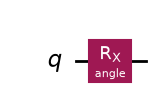

In [1]:
from qiskit.circuit import Parameter
from qiskit import QuantumCircuit

angle = Parameter("angle")  # undefined number

# Create and optimize circuit once
qc = QuantumCircuit(1)
qc.rx(angle, 0)

qc.draw("mpl")

In [2]:
qc.parameters

ParameterView([Parameter(angle)])

---
### using assign_parameters method

---

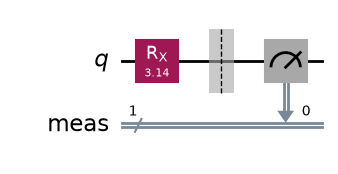

In [3]:
# bind the parameters after circuit to create a bound circuit
bc = qc.assign_parameters({angle: 3.14})
bc.measure_all()
bc.draw("mpl")

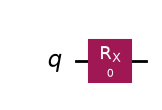

In [4]:
circuits = []
for value in range(5):
    circuits.append(qc.assign_parameters({angle: value}))

circuits[0].draw("mpl")

In [5]:
for i in range(5):
    print(circuits[i])

   ┌───────┐
q: ┤ Rx(0) ├
   └───────┘
   ┌───────┐
q: ┤ Rx(1) ├
   └───────┘
   ┌───────┐
q: ┤ Rx(2) ├
   └───────┘
   ┌───────┐
q: ┤ Rx(3) ├
   └───────┘
   ┌───────┐
q: ┤ Rx(4) ├
   └───────┘


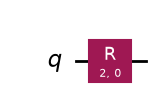

In [6]:
circuits[2].decompose().draw("mpl")

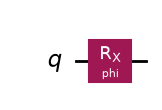

In [7]:
# Example2  :

# create the parameter
phi = Parameter("phi")
qc = QuantumCircuit(1)

# parameterize the rotation
qc.rx(phi, 0)
qc.draw("mpl")



---
## EXAMPLE: alternative way to create parameterized circuit:

### z_feature_map
- Note on default intialization 

---

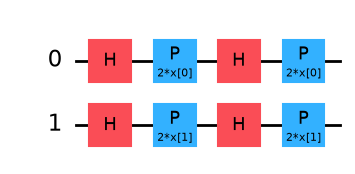

In [8]:
from qiskit.circuit.library import z_feature_map

# Define a parameterized circuit with default names
# For example, x[0]
qc = z_feature_map(2)

qc.draw("mpl")


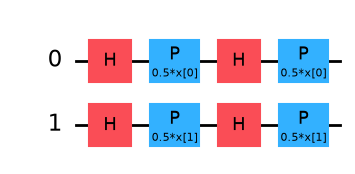

In [9]:
qc = z_feature_map(2,alpha=0.5)

qc.draw("mpl")

**NOTE:**

/var/folders/4p/ww3w4v814rn2gsbk5qj_s7vw0000gn/T/ipykernel_49126/3190941643.py:5: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  qc = ZFeatureMap(2)


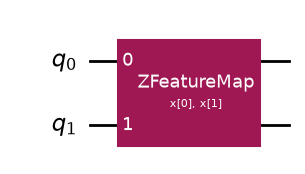

In [10]:
from qiskit.circuit.library import ZFeatureMap

# Define a parameterized circuit with default names
# For example, x[0]
qc = ZFeatureMap(2)

qc.draw("mpl")

---
### EXAMPLE : ParameterVector

---

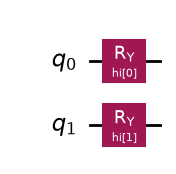

In [11]:
# Use of ParameterVector
from qiskit.circuit import ParameterVector



params_values = ParameterVector("hi", 2)

qc=QuantumCircuit(2)
qc.ry(params_values[0],0)
qc.ry(params_values[1],1)

# They will now be prefixed by `hi` instead
# For example, hi[0]

# Assign parameter names to the quantum circuit
qc_para= qc.assign_parameters(parameters=params_values)


qc.draw("mpl")

In [12]:
params_values

ParameterVector(name='hi', length=2)